In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('adult.csv')
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
print("Shape before cleaning:", df.shape)

df.replace('?', np.nan, inplace=True)
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

df_clean = df.dropna().reset_index(drop=True)
print("\nShape after cleaning:", df_clean.shape)

# Save the cleaned dataset for submission
df_clean.to_csv('adult_cleaned.csv', index=False)
df_clean.head()


Shape before cleaning: (32561, 15)
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

Missing values per column:
 workclass         1836
occupation        1843
native.country     583
dtype: int64

Shape after cleaning: (30162, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


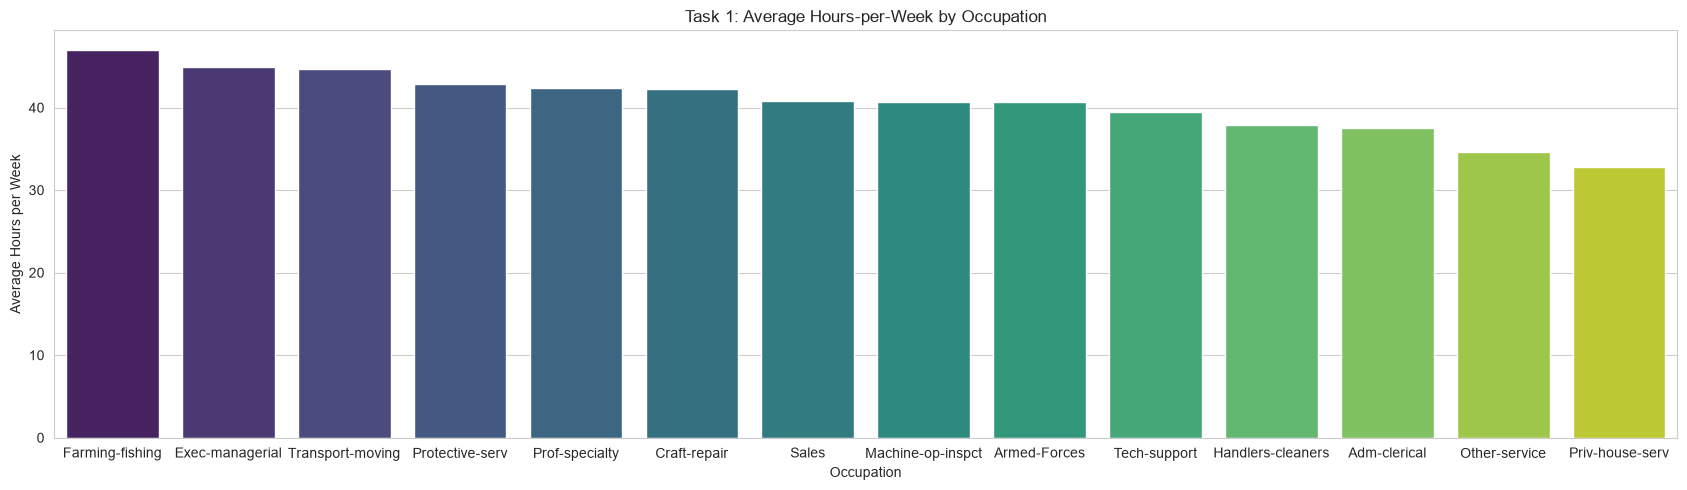

In [23]:
avg_hours_by_occ = df_clean.groupby('occupation')['hours.per.week'].mean().sort_values(ascending=False)

plt.figure(figsize=(17, 5))
sns.barplot(y=avg_hours_by_occ.values, x=avg_hours_by_occ.index, hue=avg_hours_by_occ.index,
            palette='viridis', legend=False)
plt.ylabel('Average Hours per Week')
plt.xlabel('Occupation')
plt.title('Task 1: Average Hours-per-Week by Occupation')
plt.tight_layout()

plt.show()


In [ ]:
## Task 2 



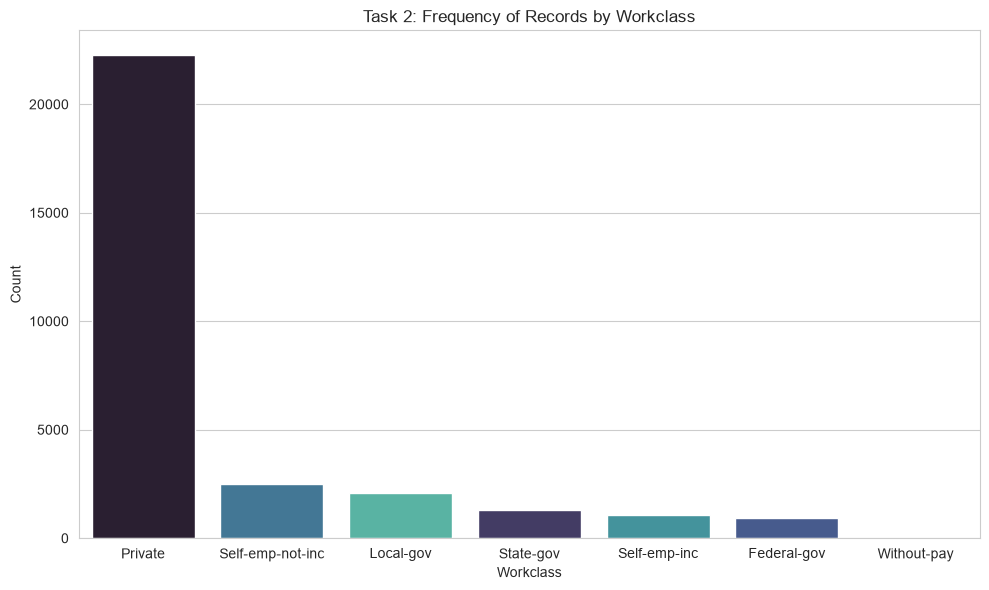

workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64

Most common category: Private


In [24]:
plt.figure(figsize=(10, 6))
order = df_clean['workclass'].value_counts().index
sns.countplot(data=df_clean, x='workclass', order=order, hue='workclass',
              palette='mako', legend=False)
plt.ylabel('Count')
plt.xlabel('Workclass')
plt.title('Task 2: Frequency of Records by Workclass')
plt.tight_layout()

plt.show()

print(df_clean['workclass'].value_counts())
most_common = df_clean['workclass'].value_counts().idxmax()
print(f"\nMost common category: {most_common}")


In [ ]:
## Task 3 


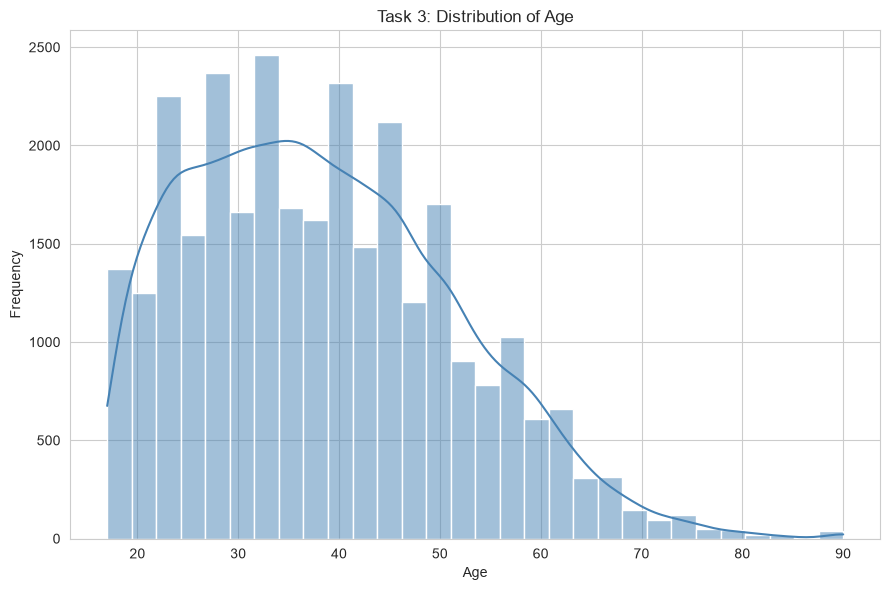

Skewness: 0.5302277818340089


In [8]:
plt.figure(figsize=(9, 6))
sns.histplot(df_clean['age'], bins=30, kde=True, color='steelblue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Task 3: Distribution of Age')
plt.tight_layout()

plt.show()

print("Skewness:", df_clean['age'].skew())


In [ ]:
## Task 4 — 

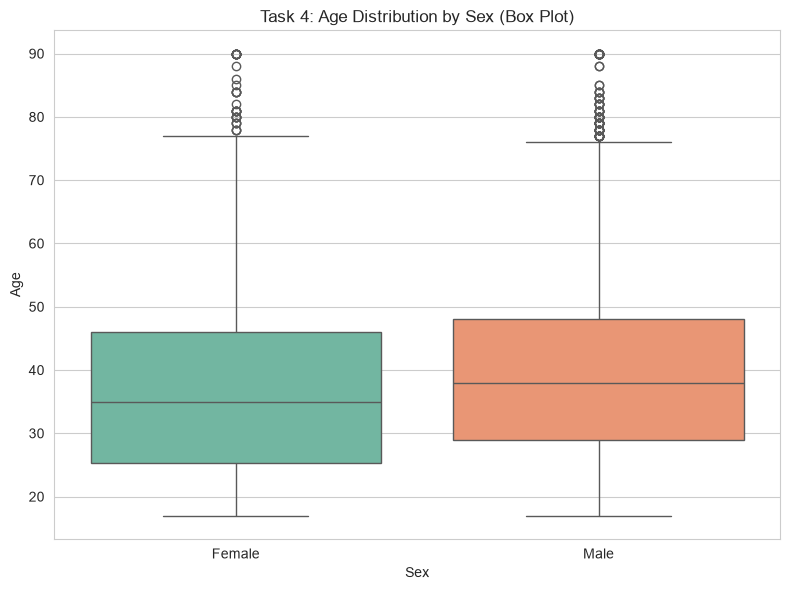

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='sex', y='age', hue='sex', palette='Set2', legend=False)
plt.xlabel('Sex')
plt.ylabel('Age')
plt.title('Task 4: Age Distribution by Sex (Box Plot)')
plt.tight_layout()

plt.show()


In [ ]:
## Task 5

In [10]:
col = 'age'
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_cleafn[col] < lower) | (df_clean[col] > upper)]

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower bound = {lower}, Upper bound = {upper}")
print(f"Number of IQR outliers: {len(outliers)}")


Q1 = 28.0, Q3 = 47.0, IQR = 19.0
Lower bound = -0.5, Upper bound = 75.5
Number of IQR outliers: 169


In [ ]:
## Task 6

In [11]:
df_clean['zscore'] = stats.zscore(df_clean['age'])
outliers_z = df_clean[df_clean['zscore'].abs() > 3]

print(f"Number of Z-score outliers: {len(outliers_z)}")
print(f"Number of IQR outliers: {len(outliers)}")


Number of Z-score outliers: 120
Number of IQR outliers: 169


In [ ]:
## Task 7

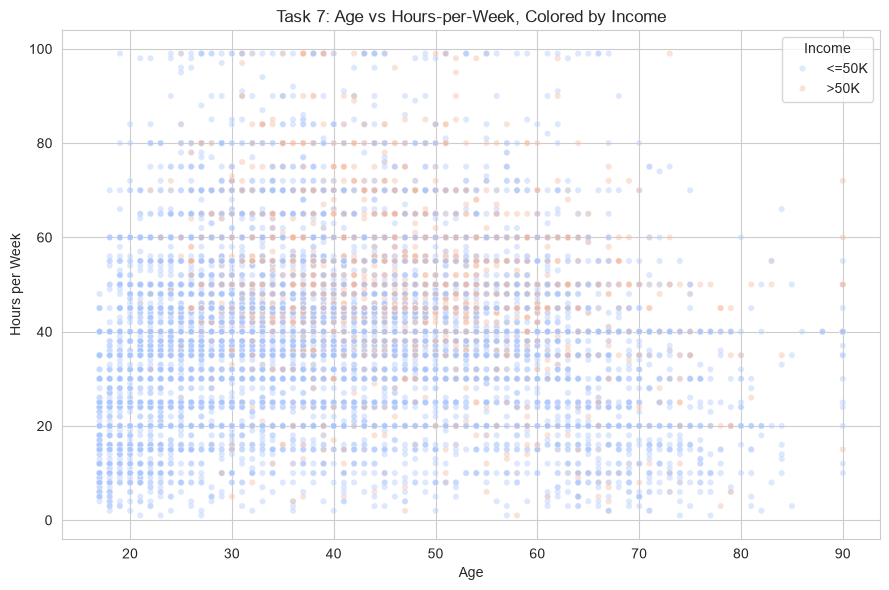

Correlation (age vs hours.per.week): 0.1015987592954843


In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clean, x='age', y='hours.per.week', hue='income',
                 alpha=0.4, palette='coolwarm', s=20)
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.title('Task 7: Age vs Hours-per-Week, Colored by Income')
plt.legend(title='Income')
plt.tight_layout()

plt.show()

print("Correlation (age vs hours.per.week):", df_clean['age'].corr(df_clean['hours.per.week']))


In [ ]:
## Task 8

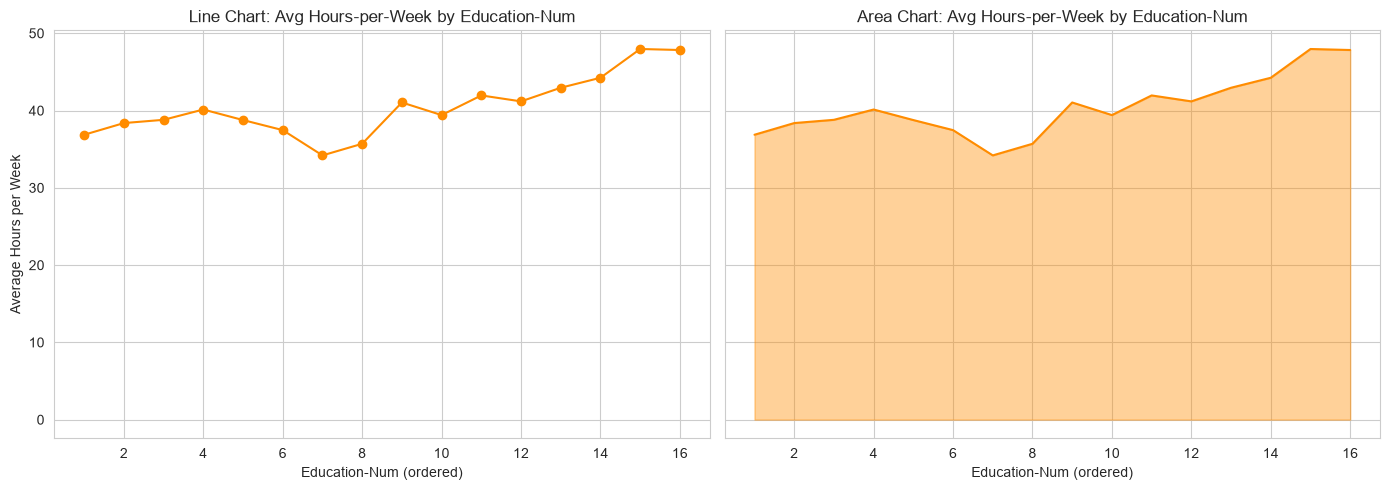

In [15]:
avg_hours_by_edu = df_clean.groupby('education.num')['hours.per.week'].mean().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker='o', color='darkorange')
axes[0].set_title('Line Chart: Avg Hours-per-Week by Education-Num')
axes[0].set_xlabel('Education-Num (ordered)')
axes[0].set_ylabel('Average Hours per Week')

axes[1].fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, color='darkorange', alpha=0.4)
axes[1].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, color='darkorange')
axes[1].set_title('Area Chart: Avg Hours-per-Week by Education-Num')
axes[1].set_xlabel('Education-Num (ordered)')

plt.tight_layout()

plt.show()


In [ ]:
## Task 9

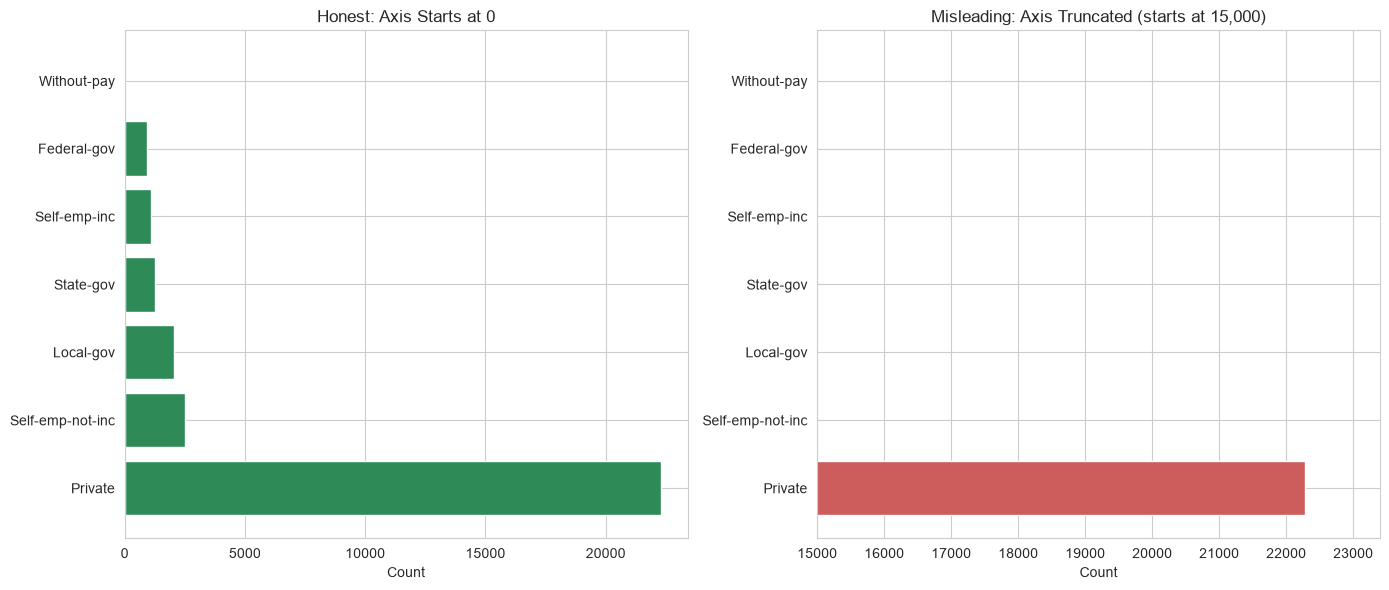

In [29]:
counts = df_clean['workclass'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Honest version - starts at 0
axes[0].barh(counts.index, counts.values, color='seagreen')
axes[0].set_xlim(left=0)
axes[0].set_xlabel('Count')
axes[0].set_title('Honest: Axis Starts at 0')

# Misleading version - truncated axis
axes[1].barh(counts.index, counts.values, color='indianred')
axes[1].set_xlim(left=15000)   # truncated starting point
axes[1].set_xlabel('Count')
axes[1].set_title('Misleading: Axis Truncated (starts at 15,000)')

plt.tight_layout()

plt.show()
